This code run under the Cebra conda environement on MacbookPro

Exploring the effect of the number of dmensions with fix model offset-5 and fix time offset of 5 steps (= 50ms at FS=100Hz)

In [41]:
import cebra
from cebra import CEBRA
import torch
if torch.cuda.is_available():
    print('using GPU')
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    print('using MPS')
    DEVICE = "mps"
else:
    print('using CPU')
    DEVICE = "cpu"

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pickle

using MPS


Load the data (time varying spike count of 208 neurons for one sample time section of day one of PurWhi, file created by 1_Read_one_NWB_Site.ipynb)

In [2]:
neuro_path = '/Users/elie/Library/CloudStorage/Box-Box/ManipBerkeleyZF/neuro_PurWhi_WF/'
filename = '%s/NeuralPop_activePeriod_countData_FS100.pkl' % (neuro_path)
neural_data = cebra.load_data(file=filename, key = 'neuralpop_data')
FS=100

In [3]:
print('recording duration:' + str(neural_data.shape[1]/100/60/60) + ' hrs or ' + str(neural_data.shape[1]/100/60) + ' min')
print('number of units: ' + str(neural_data.shape[0]))

recording duration:0.42083333333333334 hrs or 25.25 min
number of units: 208


Text(0.5, 1.0, 'Spike count data of 208 neurons')

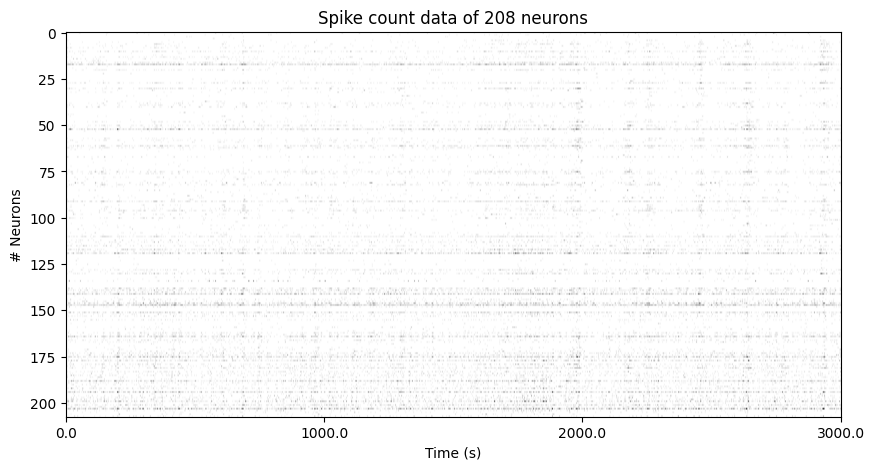

In [4]:
plt.figure(figsize=(10,5))
ax1= plt.subplot(1,1,1)
ax1.imshow(neural_data[:,:30*FS], aspect = 'auto', vmax = np.round(100*neural_data[:,:30*FS].max())/100, vmin = 0, cmap ='gray_r')
ax1.set_ylabel('# Neurons')
ax1.set_xlabel('Time (s)')
ax1.set_xticks(np.linspace(0,30*FS, 4))
ax1.set_xticklabels(np.linspace(0,30*FS, 4))
ax1.set_title('Spike count data of 208 neurons')

In [5]:
# Split data and labels into train/validation

split_idx = int(0.8 * neural_data.shape[1])
# suggestion: 5%-20% depending on your dataset size; note that this splits the
# into an early and late part, which might not be ideal for your data/experiment!
# As a more involved alternative, consider e.g. a nested time-series split.

train_data = neural_data.T[:split_idx]
valid_data = neural_data.T[split_idx:]

In [6]:
train_data.shape

(121200, 208)

In [7]:
valid_data.shape

(30300, 208)

In [8]:
# identify indices for the first two trials in the section (note that the first 3 sec of the first trial is truncated)
Time0 = 18765 # in s
TimeEnd = 20279.99 # in s
Trial1 = [18762.33, 18768.42] # in s
Trial2 = [18782.34, 18784.58] # in s
Trial3 = [18784.64, 18787.27] # in s
Trial4 = [18787.32, 18791.06] # in s

Ind_first4trials = [0, int((Trial4[1]-Time0)*FS)] # in train_data.shape

Trial5end = [20259.66, 20261.5]
Trial4end = [20261.57, 20267.74]
Trial3end = [20274.07, 20275.78]
Trial2end = [20275.85, 20277.71]
Trial1end = [20277.81, 20283.19]
Ind_last5trials = [int((Trial5end[0]-TimeEnd)*FS-1) ,-1] # in valid_data.shape and in neural_data

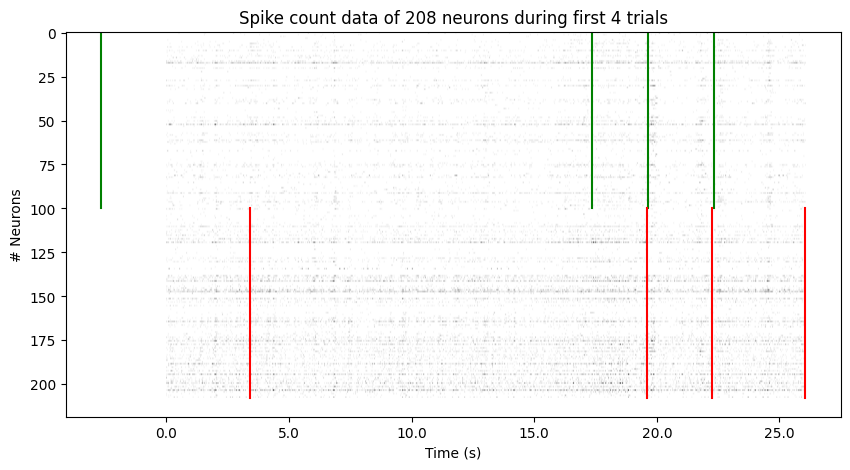

In [9]:
plt.figure(figsize=(10,5))
ax1= plt.subplot(1,1,1)
ax1.imshow(neural_data[:,Ind_first4trials[0]:Ind_first4trials[1]], aspect = 'auto', vmax = np.round(100*neural_data[:,Ind_first4trials[0]:Ind_first4trials[1]].max())/100, vmin = 0, cmap ='gray_r')
ax1.set_ylabel('# Neurons')
ax1.set_xlabel('Time (s)')
ax1.set_xticks(np.linspace(0,30*FS, 7))
ax1.set_xticklabels(np.linspace(0,30, 7))
ax1.set_title('Spike count data of 208 neurons during first 4 trials')
ax1.plot([(Trial2[0] - Time0)*FS, (Trial2[0] - Time0)*FS], [0, 100], color='green')
ax1.plot([(Trial1[0] - Time0)*FS, (Trial1[0] - Time0)*FS], [0, 100], color='green')
ax1.plot([(Trial3[0] - Time0)*FS, (Trial3[0] - Time0)*FS], [0, 100], color='green')
ax1.plot([(Trial4[0] - Time0)*FS, (Trial4[0] - Time0)*FS], [0, 100], color='green')
ax1.plot([(Trial2[1] - Time0)*FS, (Trial2[1] - Time0)*FS], [100, 208], color='red')
ax1.plot([(Trial1[1] - Time0)*FS, (Trial1[1] - Time0)*FS], [100, 208], color='red')
ax1.plot([(Trial3[1] - Time0)*FS, (Trial3[1] - Time0)*FS], [100, 208], color='red')
ax1.plot([(Trial4[1] - Time0)*FS, (Trial4[1] - Time0)*FS], [100, 208], color='red')

In [10]:
Ind_last5trials

[-2034, -1]

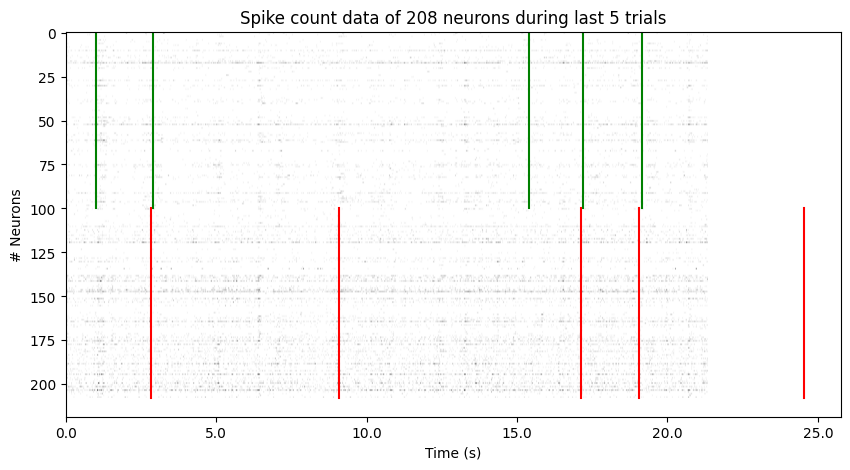

In [11]:
plt.figure(figsize=(10,5))
ax1= plt.subplot(1,1,1)
ax1.imshow(neural_data[:,Ind_last5trials[0]-FS:Ind_last5trials[1]], aspect = 'auto', vmax = np.round(100*neural_data[:,Ind_last5trials[0]-FS:Ind_last5trials[1]].max())/100, vmin = 0, cmap ='gray_r')
ax1.set_ylabel('# Neurons')
ax1.set_xlabel('Time (s)')
ax1.set_xticks(np.linspace(0,25*FS, 6))
ax1.set_xticklabels(np.linspace(0,25, 6))
ax1.set_title('Spike count data of 208 neurons during last 5 trials')
ax1.plot([FS, FS], [0, 100], color='green')
ax1.plot([(Trial4end[0]*FS - (Trial5end[0]*FS -FS)), (Trial4end[0]*FS - (Trial5end[0]*FS -FS))], [0, 100], color='green')
ax1.plot([(Trial3end[0]*FS - (Trial5end[0]*FS -FS)), (Trial3end[0]*FS - (Trial5end[0]*FS -FS))], [0, 100], color='green')
ax1.plot([(Trial2end[0]*FS - (Trial5end[0]*FS -FS)), (Trial2end[0]*FS - (Trial5end[0]*FS -FS))], [0, 100], color='green')
ax1.plot([(Trial1end[0]*FS - (Trial5end[0]*FS -FS)), (Trial1end[0]*FS - (Trial5end[0]*FS -FS))], [0, 100], color='green')
ax1.plot([(Trial5end[1]*FS - (Trial5end[0]*FS -FS)), (Trial5end[1]*FS - (Trial5end[0]*FS -FS))], [100, 208], color='red')
ax1.plot([(Trial4end[1]*FS - (Trial5end[0]*FS -FS)), (Trial4end[1]*FS - (Trial5end[0]*FS -FS))], [100, 208], color='red')
ax1.plot([(Trial3end[1]*FS - (Trial5end[0]*FS -FS)), (Trial3end[1]*FS - (Trial5end[0]*FS -FS))], [100, 208], color='red')
ax1.plot([(Trial2end[1]*FS - (Trial5end[0]*FS -FS)), (Trial2end[1]*FS - (Trial5end[0]*FS -FS))], [100, 208], color='red')
ax1.plot([(Trial1end[1]*FS - (Trial5end[0]*FS -FS)), (Trial1end[1]*FS - (Trial5end[0]*FS -FS))], [100, 208], color='red')


In [12]:
import cebra.models
print(str(len(cebra.models.get_options())) + ' different models')
print(cebra.models.get_options())
print(str(len(cebra.models.get_options('resample*'))) + ' resample models')
print(cebra.models.get_options('resample*'))
print(str(len(cebra.models.get_options('offset*'))) + ' offset models')
print(cebra.models.get_options('offset*'))
print(str(len(cebra.models.get_options('supervised*'))) + ' supervised models')
print(cebra.models.get_options('supervised*'))


147 different models
['offset10-model', 'offset10-model-mse', 'offset5-model', 'offset1-model-mse', 'offset1-model', 'offset1-model-v2', 'offset1-model-v3', 'offset1-model-v4', 'offset1-model-v5', 'offset40-model-4x-subsample', 'resample-model', 'offset20-model-4x-subsample', 'resample5-model', 'offset4-model-2x-subsample', 'resample1-model', 'supervised10-model', 'supervised1-model', 'offset36-model', 'offset36-model-dropout', 'offset36-model-more-dropout', 'offset40-model', 'offset50-model', 'offset15-model', 'offset20-model', 'offset10-model-mse-tanh', 'offset1-model-mse-tanh', 'offset1-model-mse-clip-1000-1000', 'offset1-model-mse-clip-1000-100', 'offset1-model-mse-clip-1000-50', 'offset1-model-mse-clip-1000-25', 'offset1-model-mse-clip-1000-20', 'offset1-model-mse-clip-1000-15', 'offset1-model-mse-clip-1000-10', 'offset1-model-mse-clip-1000-5', 'offset1-model-mse-clip-1000-1', 'offset1-model-mse-clip-100-1000', 'offset1-model-mse-clip-100-100', 'offset1-model-mse-clip-100-50', 'of

Defining CEBRA model for time-contrastive learning
in model.py, all different model architectures of CEBRA are defined
offset parameter is a specification of the offset to the left and right of the signal due to the network's receptive field. The offset specifies the relation between the input and output times, ``in_time - out_time = len(offset)``. (in cebra/models/model.py l74)

When defining a model, the parameter time_offsets define the distance in time steps between each reference index and its positive sample for the time contrastive learning.
The Offset parameter defined by the model architecture (ex: offset10-model vs offset5-model) corresponds to the width of the data matrix that is extrated from the data for each sample (ref, pos or neg) and centered around the time of the sample. This matrix is then fed to the convolutional neural network to calculate and optimize sample distances (it is sort of the size of the receptive field).

In our usage case, with a data sample frequency of 100Hz, and sound events that can be as short as 70ms, we want to fix the offset of the model architecture to 5 time steps = 50ms (20ms before 30ms after) and so for time contrastive learning, where the positive sample of a given ref sample is just time-offset further (after) than the ref sample, we want to fix time_offset to 3, 4 or 5 time steps (30, 40 or 50ms). The matrices of these two samples will only overlap by a little bit.

## Exploring the effect of increasing the dimensions

CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset50-model',
      output_dimension=3, time_offsets=5)
Fitting the model
calculating the training embedding
plotting the embedding for training data
calculating the validating embedding
plotting the embedding for validating data
plotting the Loss


Text(0.5, 1.0, 'Loss 3D')

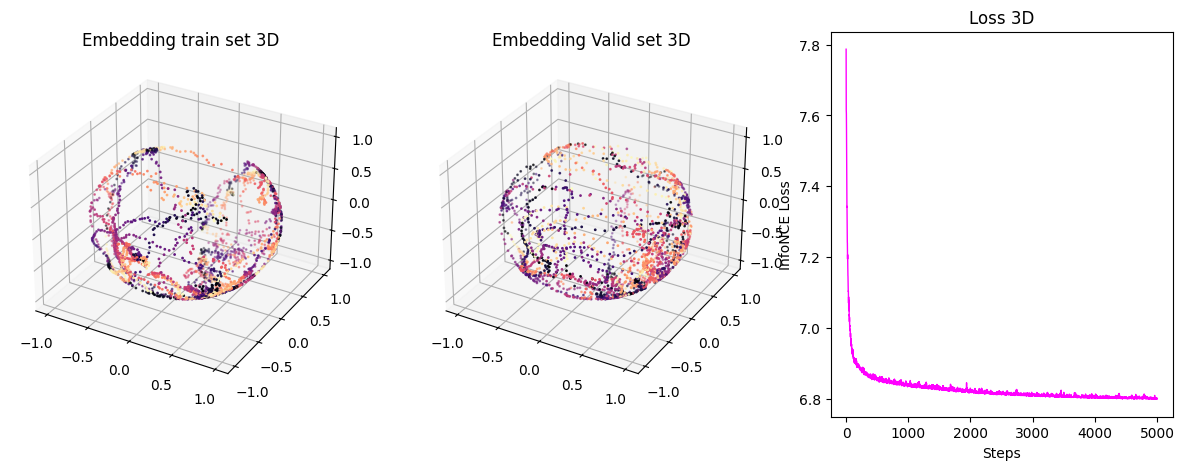

In [13]:
Output_dim = 3
cebra_3D = CEBRA(
    model_architecture = "offset50-model",
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = 5, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = False
)

print(cebra_3D)

# fit the model
print('Fitting the model')
cebra_3D.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_3D.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))
embplot = embedding[Ind_first4trials[0]:Ind_first4trials[1],:]

# plot the embedding for training set
print('plotting the embedding for training data')
fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,3,1, projection='3d') # Initialize 3D axes
colors = np.tile(np.arange(100),int(embplot.shape[0]/100)+1)
colors = colors[:len(embplot[:,0])]
ax1.scatter(embplot[:,0], embplot[:,1], embplot[:,2], cmap = 'magma', c = colors, s=1)
ax1.set_title("Embedding train set " + str(Output_dim) + "D")

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_3D.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))
embplot = embedding[Ind_last5trials[0]-FS:Ind_last5trials[1],:]

# plot the embedding for validating set
print('plotting the embedding for validating data')
ax2 = fig.add_subplot(1,3,2, projection='3d') # Initialize 3D axes
colors = np.tile(np.arange(100),int(embplot.shape[0]/100)+1)
colors = colors[:len(embplot[:,0])]
ax2.scatter(embplot[:,0], embplot[:,1], embplot[:,2], cmap = 'magma', c = colors, s=1)
ax2.set_title("Embedding Valid set " + str(Output_dim) + "D")

# plot the loss
print('plotting the Loss')
ax3 = fig.add_subplot(1,3,3)
cebra.plot_loss(cebra_3D, ax=ax3)
ax3.set_title("Loss " + str(Output_dim) + "D")

CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset50-model',
      output_dimension=4, time_offsets=5)
Fitting the model
calculating the training embedding
plotting the embedding for training data
calculating the validating embedding
plotting the embedding for validating data
plotting the Loss


Text(0.5, 1.0, 'Loss 4D')

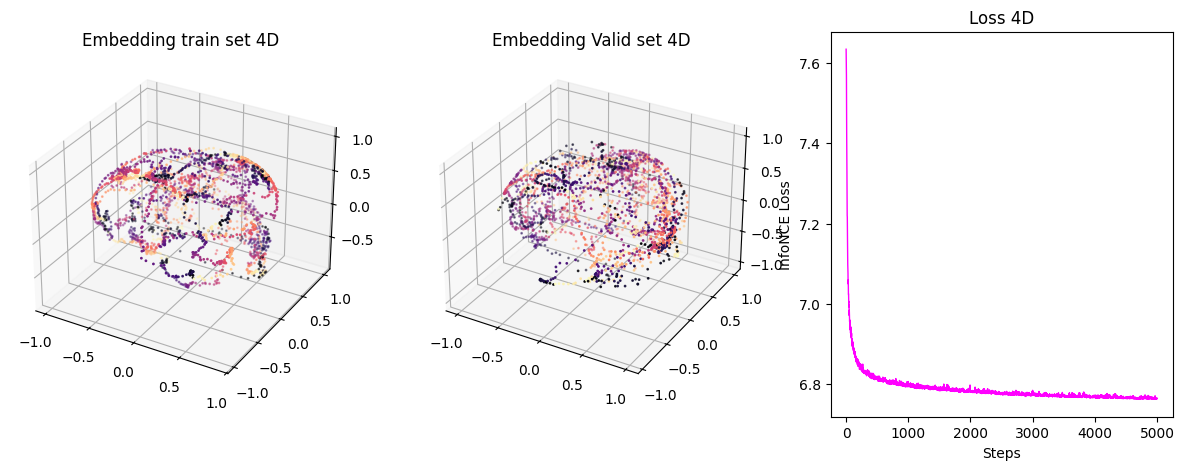

In [20]:
Output_dim = 4
cebra_4D = CEBRA(
    model_architecture = "offset50-model",
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = 5, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = False
)

print(cebra_4D)

# fit the model
print('Fitting the model')
cebra_4D.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_4D.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))
embplot = embedding[Ind_first4trials[0]:Ind_first4trials[1],:]

# plot the embedding for training set
print('plotting the embedding for training data')
fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,3,1, projection='3d') # Initialize 3D axes
colors = np.tile(np.arange(100),int(embplot.shape[0]/100)+1)
colors = colors[:len(embplot[:,0])]
ax1.scatter(embplot[:,0], embplot[:,1], embplot[:,2], cmap = 'magma', c = colors, s=1)
ax1.set_title("Embedding train set " + str(Output_dim) + "D")

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_4D.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))
embplot = embedding[Ind_last5trials[0]-FS:Ind_last5trials[1],:]

# plot the embedding for validating set
print('plotting the embedding for validating data')
ax2 = fig.add_subplot(1,3,2, projection='3d') # Initialize 3D axes
colors = np.tile(np.arange(100),int(embplot.shape[0]/100)+1)
colors = colors[:len(embplot[:,0])]
ax2.scatter(embplot[:,0], embplot[:,1], embplot[:,2], cmap = 'magma', c = colors, s=1)
ax2.set_title("Embedding Valid set " + str(Output_dim) + "D")

# plot the loss
print('plotting the Loss')
ax3 = fig.add_subplot(1,3,3)
cebra.plot_loss(cebra_4D, ax=ax3)
ax3.set_title("Loss " + str(Output_dim) + "D")

CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset50-model',
      output_dimension=5, time_offsets=5)
Fitting the model
calculating the training embedding
plotting the embedding for training data
calculating the validating embedding
plotting the embedding for validating data
plotting the Loss


Text(0.5, 1.0, 'Loss 5D')

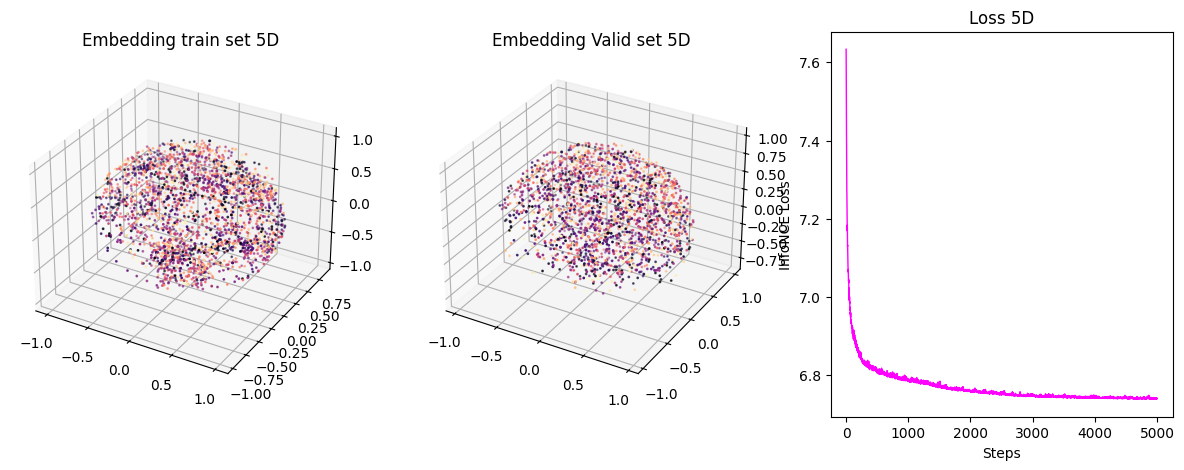

In [15]:
Output_dim = 5
cebra_5D = CEBRA(
    model_architecture = "offset50-model",
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = 5, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = False
)

print(cebra_5D)

# fit the model
print('Fitting the model')
cebra_5D.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_5D.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))
embplot = embedding[Ind_first4trials[0]:Ind_first4trials[1],:]

# plot the embedding for training set
print('plotting the embedding for training data')
fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,3,1, projection='3d') # Initialize 3D axes
colors = np.tile(np.arange(100),int(embplot.shape[0]/100)+1)
colors = colors[:len(embplot[:,0])]
ax1.scatter(embplot[:,0], embplot[:,1], embplot[:,2], cmap = 'magma', c = colors, s=1)
ax1.set_title("Embedding train set " + str(Output_dim) + "D")

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_5D.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))
embplot = embedding[Ind_last5trials[0]-FS:Ind_last5trials[1],:]

# plot the embedding for validating set
print('plotting the embedding for validating data')
ax2 = fig.add_subplot(1,3,2, projection='3d') # Initialize 3D axes
colors = np.tile(np.arange(100),int(embplot.shape[0]/100)+1)
colors = colors[:len(embplot[:,0])]
ax2.scatter(embplot[:,0], embplot[:,1], embplot[:,2], cmap = 'magma', c = colors, s=1)
ax2.set_title("Embedding Valid set " + str(Output_dim) + "D")

# plot the loss
print('plotting the Loss')
ax3 = fig.add_subplot(1,3,3)
cebra.plot_loss(cebra_5D, ax=ax3)
ax3.set_title("Loss " + str(Output_dim) + "D")

CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset50-model',
      output_dimension=6, time_offsets=5)
Fitting the model
calculating the training embedding
plotting the embedding for training data
calculating the validating embedding
plotting the embedding for validating data
plotting the Loss


Text(0.5, 1.0, 'Loss 6D')

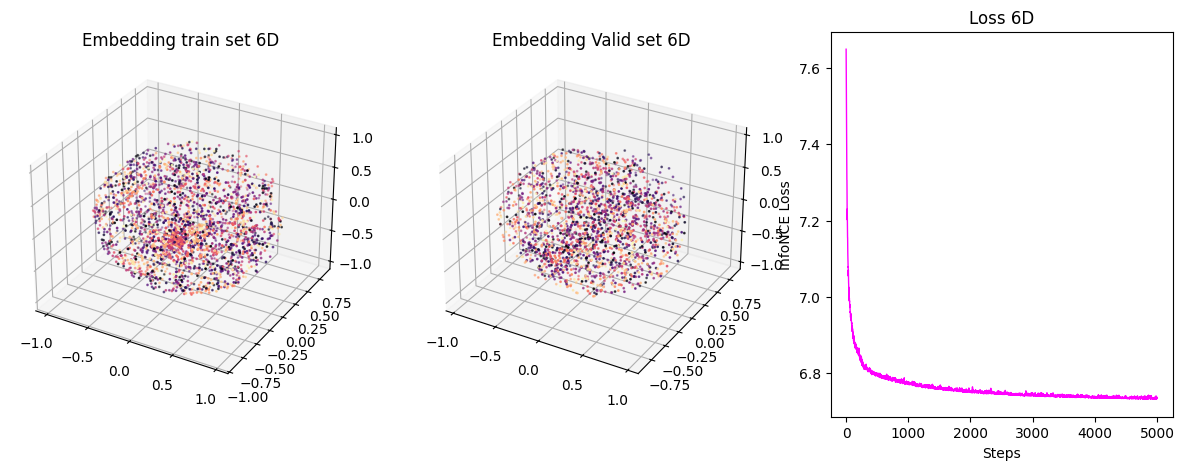

In [16]:
Output_dim = 6
cebra_6D = CEBRA(
    model_architecture = "offset50-model",
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = 5, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = False
)

print(cebra_6D)

# fit the model
print('Fitting the model')
cebra_6D.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_6D.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))
embplot = embedding[Ind_first4trials[0]:Ind_first4trials[1],:]

# plot the embedding for training set
print('plotting the embedding for training data')
fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,3,1, projection='3d') # Initialize 3D axes
colors = np.tile(np.arange(100),int(embplot.shape[0]/100)+1)
colors = colors[:len(embplot[:,0])]
ax1.scatter(embplot[:,0], embplot[:,1], embplot[:,2], cmap = 'magma', c = colors, s=1)
ax1.set_title("Embedding train set " + str(Output_dim) + "D")

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_6D.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))
embplot = embedding[Ind_last5trials[0]-FS:Ind_last5trials[1],:]

# plot the embedding for validating set
print('plotting the embedding for validating data')
ax2 = fig.add_subplot(1,3,2, projection='3d') # Initialize 3D axes
colors = np.tile(np.arange(100),int(embplot.shape[0]/100)+1)
colors = colors[:len(embplot[:,0])]
ax2.scatter(embplot[:,0], embplot[:,1], embplot[:,2], cmap = 'magma', c = colors, s=1)
ax2.set_title("Embedding Valid set " + str(Output_dim) + "D")

# plot the loss
print('plotting the Loss')
ax3 = fig.add_subplot(1,3,3)
cebra.plot_loss(cebra_6D, ax=ax3)
ax3.set_title("Loss " + str(Output_dim) + "D")

CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset50-model',
      output_dimension=7, time_offsets=5)
Fitting the model
calculating the training embedding
plotting the embedding for training data
calculating the validating embedding
plotting the embedding for validating data
plotting the Loss


Text(0.5, 1.0, 'Loss 7D')

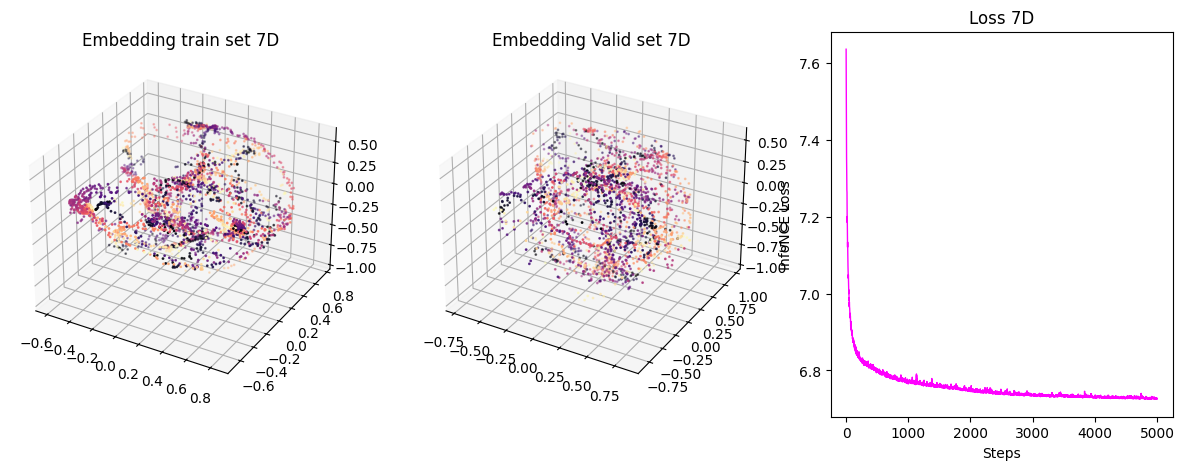

In [17]:
Output_dim = 7
cebra_7D = CEBRA(
    model_architecture = "offset50-model",
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = 5, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = False
)

print(cebra_7D)

# fit the model
print('Fitting the model')
cebra_7D.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_7D.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))
embplot = embedding[Ind_first4trials[0]:Ind_first4trials[1],:]

# plot the embedding for training set
print('plotting the embedding for training data')
fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,3,1, projection='3d') # Initialize 3D axes
colors = np.tile(np.arange(100),int(embplot.shape[0]/100)+1)
colors = colors[:len(embplot[:,0])]
ax1.scatter(embplot[:,0], embplot[:,1], embplot[:,2], cmap = 'magma', c = colors, s=1)
ax1.set_title("Embedding train set " + str(Output_dim) + "D")

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_7D.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))
embplot = embedding[Ind_last5trials[0]-FS:Ind_last5trials[1],:]

# plot the embedding for validating set
print('plotting the embedding for validating data')
ax2 = fig.add_subplot(1,3,2, projection='3d') # Initialize 3D axes
colors = np.tile(np.arange(100),int(embplot.shape[0]/100)+1)
colors = colors[:len(embplot[:,0])]
ax2.scatter(embplot[:,0], embplot[:,1], embplot[:,2], cmap = 'magma', c = colors, s=1)
ax2.set_title("Embedding Valid set " + str(Output_dim) + "D")

# plot the loss
print('plotting the Loss')
ax3 = fig.add_subplot(1,3,3)
cebra.plot_loss(cebra_7D, ax=ax3)
ax3.set_title("Loss " + str(Output_dim) + "D")

CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset50-model', time_offsets=5)
Fitting the model
calculating the training embedding
plotting the embedding for training data
calculating the validating embedding
plotting the embedding for validating data
plotting the Loss


Text(0.5, 1.0, 'Loss 8D')

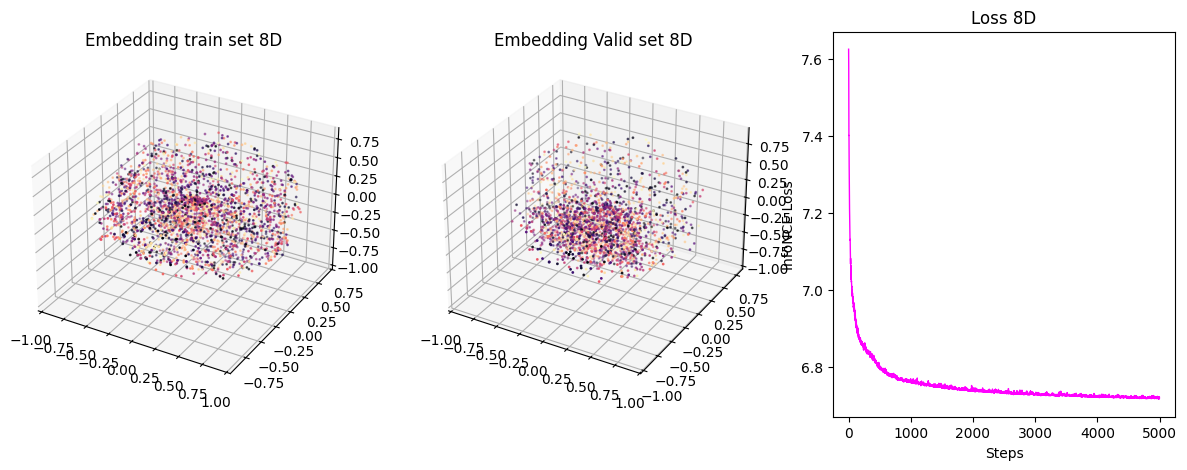

In [18]:
Output_dim = 8
cebra_8D = CEBRA(
    model_architecture = "offset50-model",
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = 5, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = False
)

print(cebra_8D)

# fit the model
print('Fitting the model')
cebra_8D.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_8D.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))
embplot = embedding[Ind_first4trials[0]:Ind_first4trials[1],:]

# plot the embedding for training set
print('plotting the embedding for training data')
fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,3,1, projection='3d') # Initialize 3D axes
colors = np.tile(np.arange(100),int(embplot.shape[0]/100)+1)
colors = colors[:len(embplot[:,0])]
ax1.scatter(embplot[:,0], embplot[:,1], embplot[:,2], cmap = 'magma', c = colors, s=1)
ax1.set_title("Embedding train set " + str(Output_dim) + "D")

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_8D.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))
embplot = embedding[Ind_last5trials[0]-FS:Ind_last5trials[1],:]

# plot the embedding for validating set
print('plotting the embedding for validating data')
ax2 = fig.add_subplot(1,3,2, projection='3d') # Initialize 3D axes
colors = np.tile(np.arange(100),int(embplot.shape[0]/100)+1)
colors = colors[:len(embplot[:,0])]
ax2.scatter(embplot[:,0], embplot[:,1], embplot[:,2], cmap = 'magma', c = colors, s=1)
ax2.set_title("Embedding Valid set " + str(Output_dim) + "D")

# plot the loss
print('plotting the Loss')
ax3 = fig.add_subplot(1,3,3)
cebra.plot_loss(cebra_8D, ax=ax3)
ax3.set_title("Loss " + str(Output_dim) + "D")

CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset50-model',
      output_dimension=10, time_offsets=5)
Fitting the model
calculating the training embedding
plotting the embedding for training data
calculating the validating embedding
plotting the embedding for validating data
plotting the Loss


Text(0.5, 1.0, 'Loss 10D')

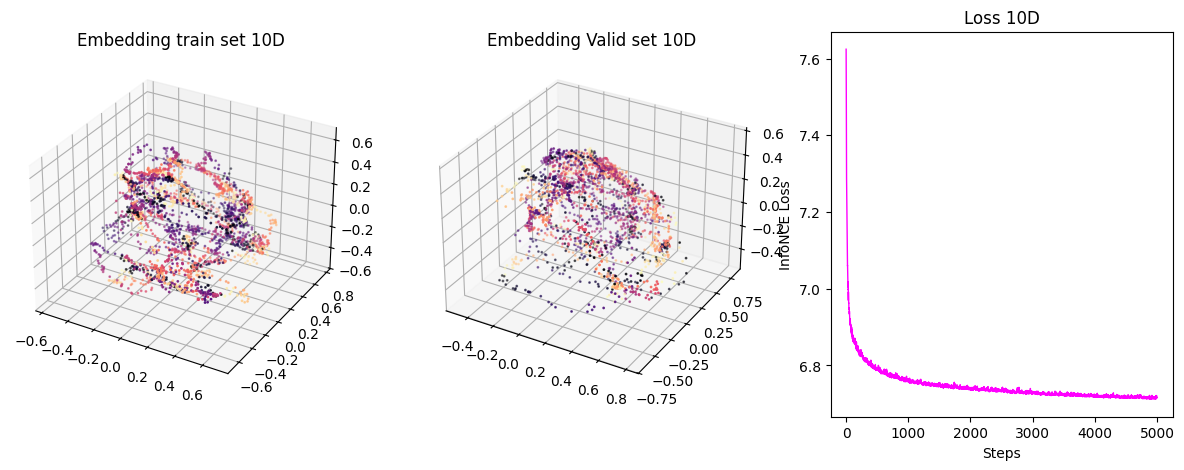

In [21]:
Output_dim = 10
cebra_10D = CEBRA(
    model_architecture = "offset50-model",
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = 5, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = False
)

print(cebra_10D)

# fit the model
print('Fitting the model')
cebra_10D.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_10D.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))
embplot = embedding[Ind_first4trials[0]:Ind_first4trials[1],:]

# plot the embedding for training set
print('plotting the embedding for training data')
fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,3,1, projection='3d') # Initialize 3D axes
colors = np.tile(np.arange(100),int(embplot.shape[0]/100)+1)
colors = colors[:len(embplot[:,0])]
ax1.scatter(embplot[:,0], embplot[:,1], embplot[:,2], cmap = 'magma', c = colors, s=1)
ax1.set_title("Embedding train set " + str(Output_dim) + "D")

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_10D.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))
embplot = embedding[Ind_last5trials[0]-FS:Ind_last5trials[1],:]

# plot the embedding for validating set
print('plotting the embedding for validating data')
ax2 = fig.add_subplot(1,3,2, projection='3d') # Initialize 3D axes
colors = np.tile(np.arange(100),int(embplot.shape[0]/100)+1)
colors = colors[:len(embplot[:,0])]
ax2.scatter(embplot[:,0], embplot[:,1], embplot[:,2], cmap = 'magma', c = colors, s=1)
ax2.set_title("Embedding Valid set " + str(Output_dim) + "D")

# plot the loss
print('plotting the Loss')
ax3 = fig.add_subplot(1,3,3)
cebra.plot_loss(cebra_10D, ax=ax3)
ax3.set_title("Loss " + str(Output_dim) + "D")

CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset50-model',
      output_dimension=20, time_offsets=5)
Fitting the model
calculating the training embedding
plotting the embedding for training data
calculating the validating embedding
plotting the embedding for validating data
plotting the Loss


Text(0.5, 1.0, 'Loss 20D')

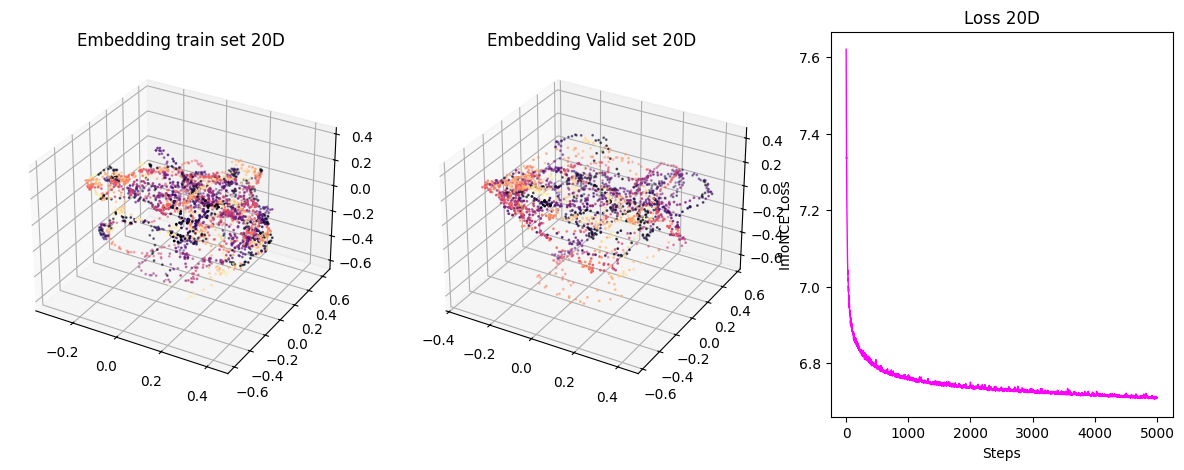

In [22]:
Output_dim = 20
cebra_20D = CEBRA(
    model_architecture = "offset50-model",
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = 5, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = False
)

print(cebra_20D)

# fit the model
print('Fitting the model')
cebra_20D.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_20D.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))
embplot = embedding[Ind_first4trials[0]:Ind_first4trials[1],:]

# plot the embedding for training set
print('plotting the embedding for training data')
fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,3,1, projection='3d') # Initialize 3D axes
colors = np.tile(np.arange(100),int(embplot.shape[0]/100)+1)
colors = colors[:len(embplot[:,0])]
ax1.scatter(embplot[:,0], embplot[:,1], embplot[:,2], cmap = 'magma', c = colors, s=1)
ax1.set_title("Embedding train set " + str(Output_dim) + "D")

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_20D.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))
embplot = embedding[Ind_last5trials[0]-FS:Ind_last5trials[1],:]

# plot the embedding for validating set
print('plotting the embedding for validating data')
ax2 = fig.add_subplot(1,3,2, projection='3d') # Initialize 3D axes
colors = np.tile(np.arange(100),int(embplot.shape[0]/100)+1)
colors = colors[:len(embplot[:,0])]
ax2.scatter(embplot[:,0], embplot[:,1], embplot[:,2], cmap = 'magma', c = colors, s=1)
ax2.set_title("Embedding Valid set " + str(Output_dim) + "D")

# plot the loss
print('plotting the Loss')
ax3 = fig.add_subplot(1,3,3)
cebra.plot_loss(cebra_20D, ax=ax3)
ax3.set_title("Loss " + str(Output_dim) + "D")

CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset50-model',
      output_dimension=50, time_offsets=5)
Fitting the model
calculating the training embedding
plotting the embedding for training data
calculating the validating embedding
plotting the embedding for validating data
plotting the Loss


Text(0.5, 1.0, 'Loss 50D')

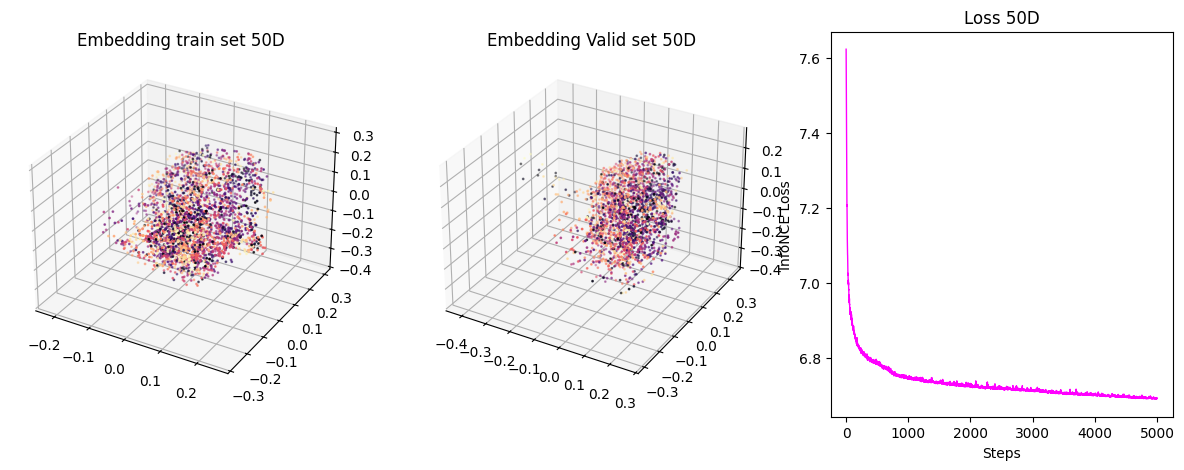

In [23]:
Output_dim = 50
cebra_50D = CEBRA(
    model_architecture = "offset50-model",
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = 5, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = False
)

print(cebra_50D)

# fit the model
print('Fitting the model')
cebra_50D.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_50D.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))
embplot = embedding[Ind_first4trials[0]:Ind_first4trials[1],:]

# plot the embedding for training set
print('plotting the embedding for training data')
fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,3,1, projection='3d') # Initialize 3D axes
colors = np.tile(np.arange(100),int(embplot.shape[0]/100)+1)
colors = colors[:len(embplot[:,0])]
ax1.scatter(embplot[:,0], embplot[:,1], embplot[:,2], cmap = 'magma', c = colors, s=1)
ax1.set_title("Embedding train set " + str(Output_dim) + "D")

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_50D.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))
embplot = embedding[Ind_last5trials[0]-FS:Ind_last5trials[1],:]

# plot the embedding for validating set
print('plotting the embedding for validating data')
ax2 = fig.add_subplot(1,3,2, projection='3d') # Initialize 3D axes
colors = np.tile(np.arange(100),int(embplot.shape[0]/100)+1)
colors = colors[:len(embplot[:,0])]
ax2.scatter(embplot[:,0], embplot[:,1], embplot[:,2], cmap = 'magma', c = colors, s=1)
ax2.set_title("Embedding Valid set " + str(Output_dim) + "D")

# plot the loss
print('plotting the Loss')
ax3 = fig.add_subplot(1,3,3)
cebra.plot_loss(cebra_50D, ax=ax3)
ax3.set_title("Loss " + str(Output_dim) + "D")

CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset50-model',
      output_dimension=100, time_offsets=5)
Fitting the model
calculating the training embedding
plotting the embedding for training data
calculating the validating embedding
plotting the embedding for validating data
plotting the Loss


Text(0.5, 1.0, 'Loss 100D')

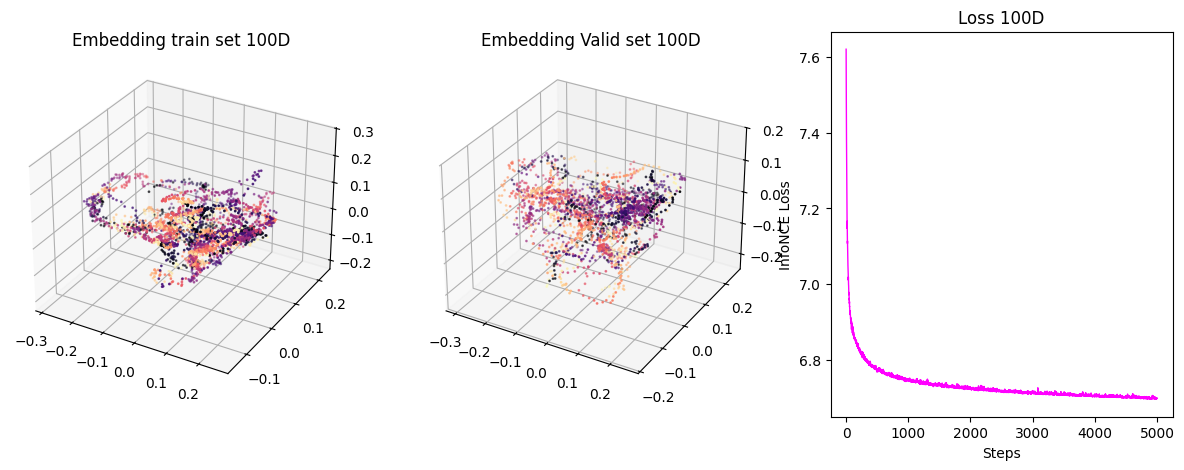

In [24]:
Output_dim = 100
cebra_100D = CEBRA(
    model_architecture = "offset50-model",
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = 5, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = False
)

print(cebra_100D)

# fit the model
print('Fitting the model')
cebra_100D.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_100D.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))
embplot = embedding[Ind_first4trials[0]:Ind_first4trials[1],:]

# plot the embedding for training set
print('plotting the embedding for training data')
fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,3,1, projection='3d') # Initialize 3D axes
colors = np.tile(np.arange(100),int(embplot.shape[0]/100)+1)
colors = colors[:len(embplot[:,0])]
ax1.scatter(embplot[:,0], embplot[:,1], embplot[:,2], cmap = 'magma', c = colors, s=1)
ax1.set_title("Embedding train set " + str(Output_dim) + "D")

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_100D.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))
embplot = embedding[Ind_last5trials[0]-FS:Ind_last5trials[1],:]

# plot the embedding for validating set
print('plotting the embedding for validating data')
ax2 = fig.add_subplot(1,3,2, projection='3d') # Initialize 3D axes
colors = np.tile(np.arange(100),int(embplot.shape[0]/100)+1)
colors = colors[:len(embplot[:,0])]
ax2.scatter(embplot[:,0], embplot[:,1], embplot[:,2], cmap = 'magma', c = colors, s=1)
ax2.set_title("Embedding Valid set " + str(Output_dim) + "D")

# plot the loss
print('plotting the Loss')
ax3 = fig.add_subplot(1,3,3)
cebra.plot_loss(cebra_100D, ax=ax3)
ax3.set_title("Loss " + str(Output_dim) + "D")

CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset50-model',
      output_dimension=150, time_offsets=5)
Fitting the model
calculating the training embedding
plotting the embedding for training data
calculating the validating embedding
plotting the embedding for validating data
plotting the Loss


Text(0.5, 1.0, 'Loss 150D')

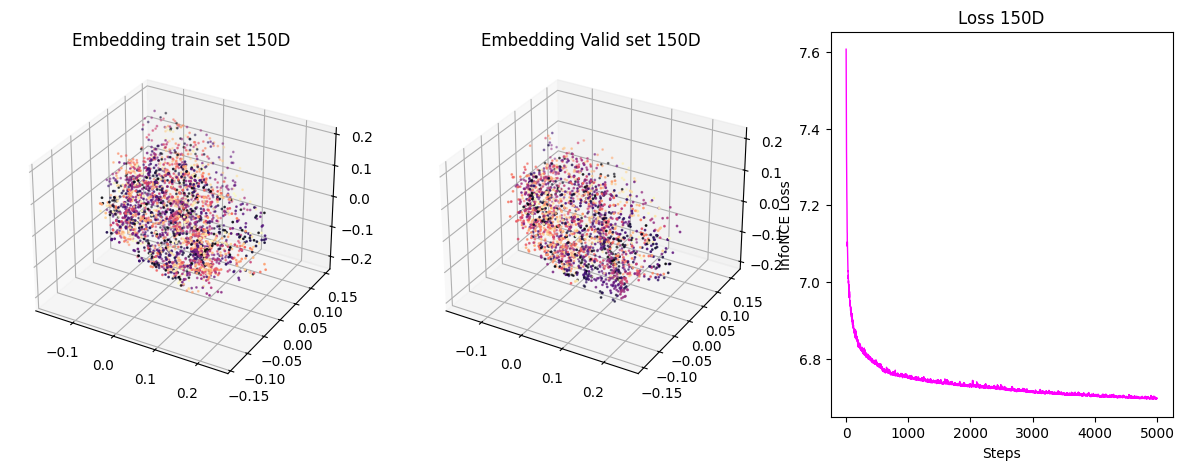

In [25]:
Output_dim = 150
cebra_150D = CEBRA(
    model_architecture = "offset50-model",
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = 5, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = False
)

print(cebra_150D)

# fit the model
print('Fitting the model')
cebra_150D.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_150D.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))
embplot = embedding[Ind_first4trials[0]:Ind_first4trials[1],:]

# plot the embedding for training set
print('plotting the embedding for training data')
fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,3,1, projection='3d') # Initialize 3D axes
colors = np.tile(np.arange(100),int(embplot.shape[0]/100)+1)
colors = colors[:len(embplot[:,0])]
ax1.scatter(embplot[:,0], embplot[:,1], embplot[:,2], cmap = 'magma', c = colors, s=1)
ax1.set_title("Embedding train set " + str(Output_dim) + "D")

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_150D.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))
embplot = embedding[Ind_last5trials[0]-FS:Ind_last5trials[1],:]

# plot the embedding for validating set
print('plotting the embedding for validating data')
ax2 = fig.add_subplot(1,3,2, projection='3d') # Initialize 3D axes
colors = np.tile(np.arange(100),int(embplot.shape[0]/100)+1)
colors = colors[:len(embplot[:,0])]
ax2.scatter(embplot[:,0], embplot[:,1], embplot[:,2], cmap = 'magma', c = colors, s=1)
ax2.set_title("Embedding Valid set " + str(Output_dim) + "D")

# plot the loss
print('plotting the Loss')
ax3 = fig.add_subplot(1,3,3)
cebra.plot_loss(cebra_150D, ax=ax3)
ax3.set_title("Loss " + str(Output_dim) + "D")

CEBRA(batch_size=2048, conditional='time', device='mps', learning_rate=0.001,
      max_iterations=5000, model_architecture='offset50-model',
      output_dimension=200, time_offsets=5)
Fitting the model
calculating the training embedding
plotting the embedding for training data
calculating the validating embedding
plotting the embedding for validating data
plotting the Loss


Text(0.5, 1.0, 'Loss 200D')

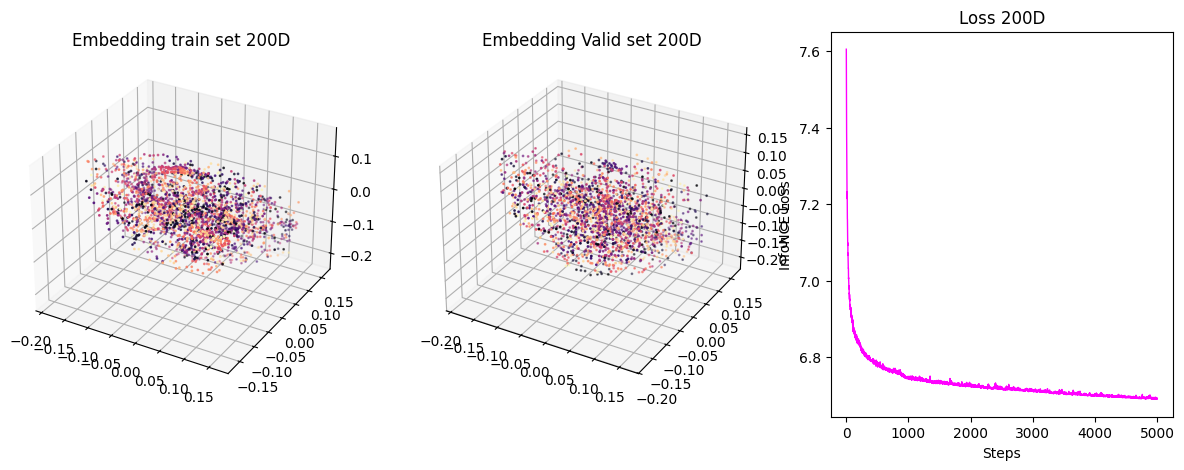

In [26]:
Output_dim = 200
cebra_200D = CEBRA(
    model_architecture = "offset50-model",
    conditional = 'time',
    batch_size = 2048, # could be 1024, CEBRA should be trained on the biggest batch size possible
    learning_rate = 0.001,
    max_iterations = 5000,#use at least 10,000 iterations to train the model. For prototyping, start with a smaller number (a few 1,000 iterations), increase if the model does not converge (cloud-like)
    time_offsets = 5, #distance (in time) between positive pairs and informs the algorithm about the time-scale of interest
    output_dimension = Output_dim,
    device = DEVICE,
    verbose = False
)

print(cebra_200D)

# fit the model
print('Fitting the model')
cebra_200D.fit(train_data)

# obtain the embedding on training set
print('calculating the training embedding')
embedding = cebra_200D.transform(train_data)
assert(embedding.shape == (train_data.shape[0],Output_dim))
embplot = embedding[Ind_first4trials[0]:Ind_first4trials[1],:]

# plot the embedding for training set
print('plotting the embedding for training data')
fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(1,3,1, projection='3d') # Initialize 3D axes
colors = np.tile(np.arange(100),int(embplot.shape[0]/100)+1)
colors = colors[:len(embplot[:,0])]
ax1.scatter(embplot[:,0], embplot[:,1], embplot[:,2], cmap = 'magma', c = colors, s=1)
ax1.set_title("Embedding train set " + str(Output_dim) + "D")

# obtain the embedding on validating set
print('calculating the validating embedding')
embedding = cebra_200D.transform(valid_data)
assert(embedding.shape == (valid_data.shape[0],Output_dim))
embplot = embedding[Ind_last5trials[0]-FS:Ind_last5trials[1],:]

# plot the embedding for validating set
print('plotting the embedding for validating data')
ax2 = fig.add_subplot(1,3,2, projection='3d') # Initialize 3D axes
colors = np.tile(np.arange(100),int(embplot.shape[0]/100)+1)
colors = colors[:len(embplot[:,0])]
ax2.scatter(embplot[:,0], embplot[:,1], embplot[:,2], cmap = 'magma', c = colors, s=1)
ax2.set_title("Embedding Valid set " + str(Output_dim) + "D")

# plot the loss
print('plotting the Loss')
ax3 = fig.add_subplot(1,3,3)
cebra.plot_loss(cebra_200D, ax=ax3)
ax3.set_title("Loss " + str(Output_dim) + "D")

<Axes: xlabel='Steps', ylabel='InfoNCE Loss'>

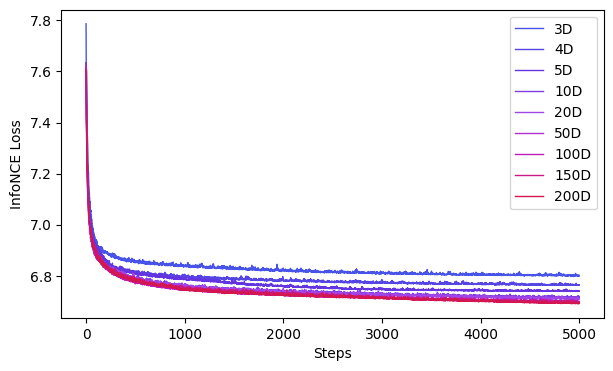

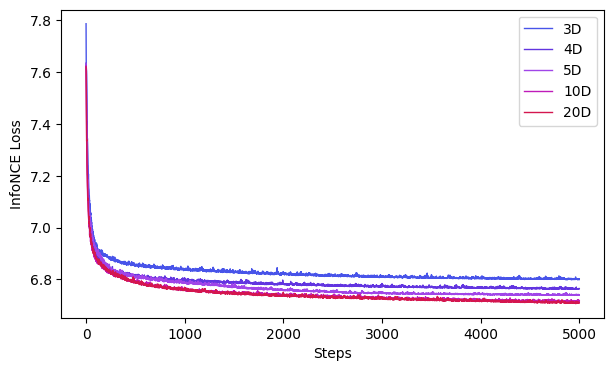

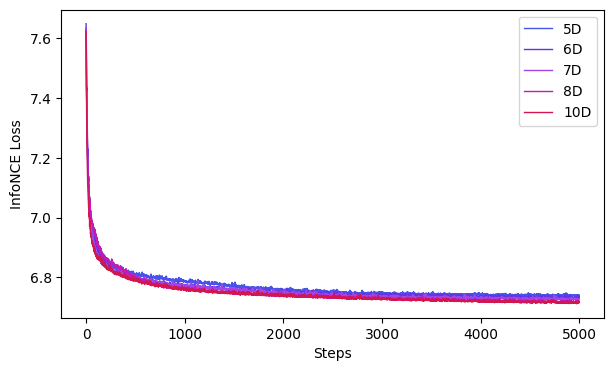

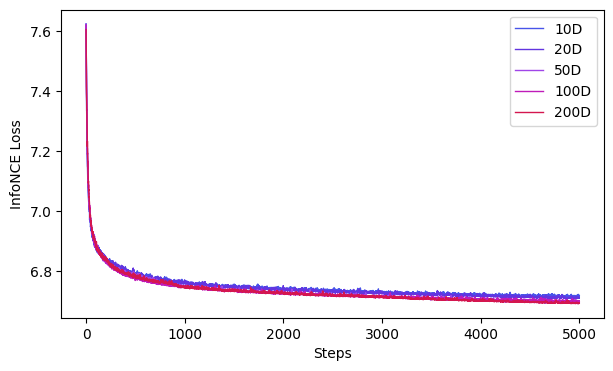

In [32]:
# compare Losses
# Labels to be used for the legend of the plot
labels = ["3D","4D","5D", "10D", "20D", "50D", "100D", "150D", "200D"]
cebra.compare_models([cebra_3D, cebra_4D, cebra_5D, cebra_10D, cebra_20D, cebra_50D, cebra_100D, cebra_150D, cebra_200D], labels)

# Labels to be used for the legend of the plot
labels = ["3D", "4D", "5D", "10D", "20D"]
cebra.compare_models([cebra_3D, cebra_4D, cebra_5D, cebra_10D, cebra_20D], labels)

# Labels to be used for the legend of the plot
labels = ["5D", "6D", "7D", "8D", "10D"]
cebra.compare_models([cebra_5D, cebra_6D, cebra_7D, cebra_8D, cebra_10D], labels)

# Labels to be used for the legend of the plot
labels = ["10D", "20D", "50D", "100D", "200D"]
cebra.compare_models([cebra_10D, cebra_20D, cebra_50D, cebra_100D, cebra_200D], labels)


Text(0.5, 0, 'Dimensions')

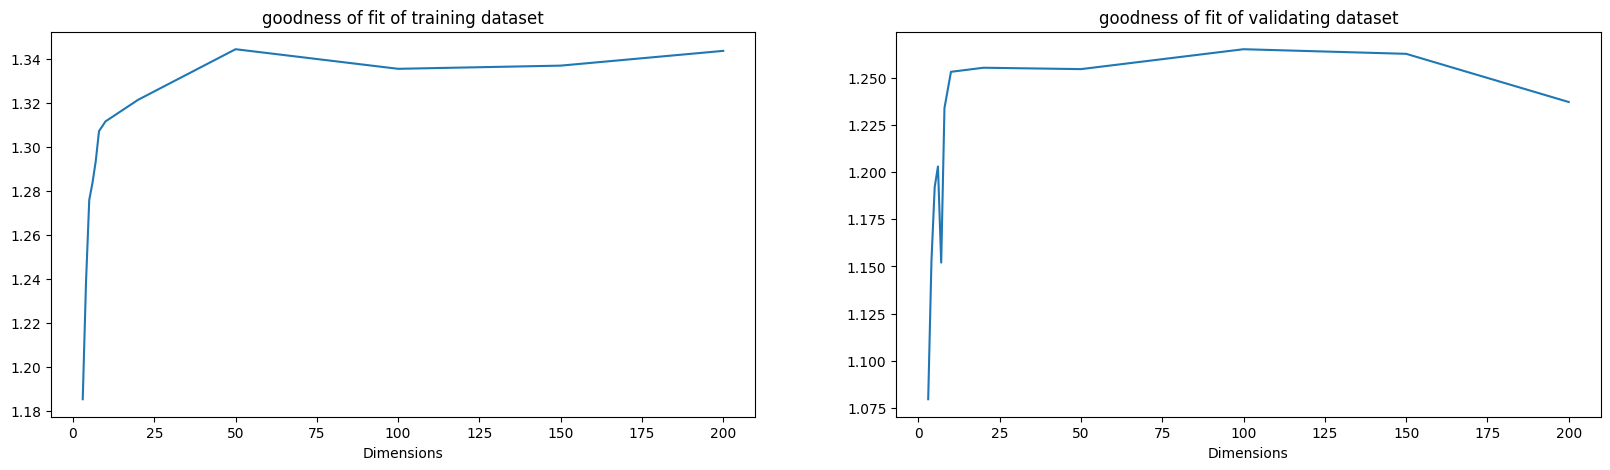

In [33]:
# Evaluate the model performance
goodness_of_fit_train = []
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_3D,
                                                     train_data))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_4D,
                                                     train_data))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_5D,
                                                     train_data))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_6D,
                                                     train_data))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_7D,
                                                     train_data))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_8D,
                                                     train_data))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_10D,
                                                     train_data))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_20D,
                                                     train_data))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_50D,
                                                     train_data))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_100D,
                                                     train_data))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_150D,
                                                     train_data))
goodness_of_fit_train.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_200D,
                                                     train_data))
fig = plt.figure(figsize=(20,5))
ax1 = fig.add_subplot(1,2,1)
ax1.plot([3,4,5,6,7,8,10,20,50,100,150,200], goodness_of_fit_train)
ax1.set_title('goodness of fit of training dataset')
ax1.set_xlabel('Dimensions')

goodness_of_fit_valid = []
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_3D,
                                                     valid_data))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_4D,
                                                     valid_data))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_5D,
                                                     valid_data))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_6D,
                                                     valid_data))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_7D,
                                                     valid_data))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_8D,
                                                     valid_data))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_10D,
                                                     valid_data))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_20D,
                                                     valid_data))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_50D,
                                                     valid_data))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_100D,
                                                     valid_data))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_150D,
                                                     valid_data))
goodness_of_fit_valid.append(cebra.sklearn.metrics.goodness_of_fit_score(cebra_200D,
                                                     valid_data))
ax2 = fig.add_subplot(1,2,2)
ax2.plot([3,4,5,6,7,8,10,20,50,100,150,200], goodness_of_fit_valid)
ax2.set_title('goodness of fit of validating dataset')
ax2.set_xlabel('Dimensions')

Text(0.5, 0, 'Dimensions')

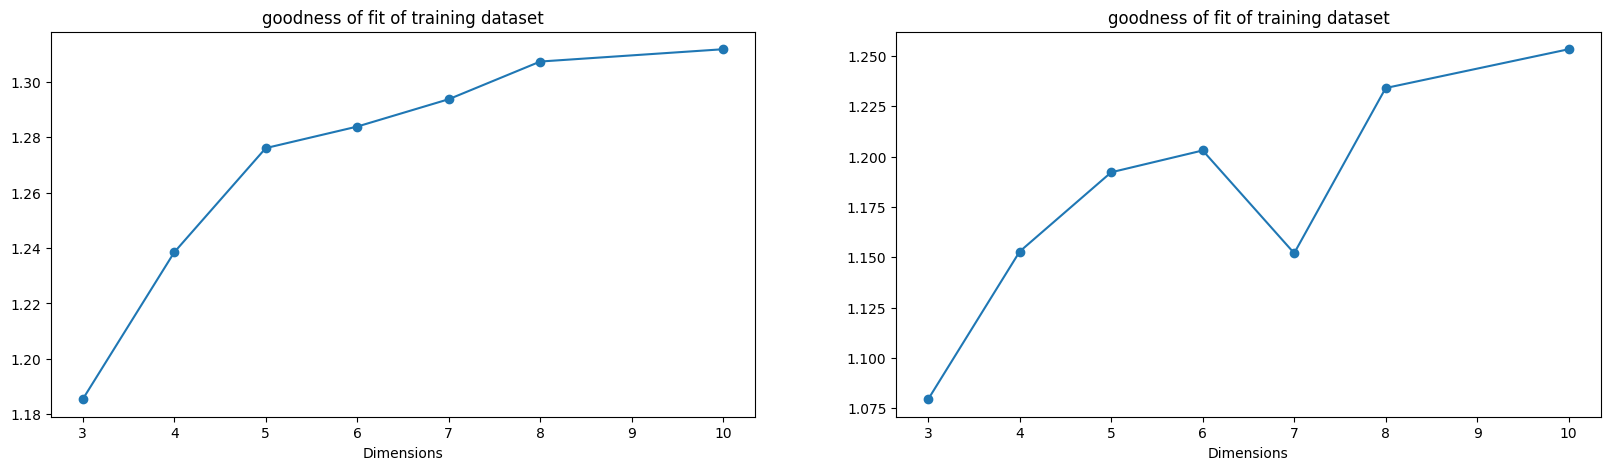

In [ ]:
fig = plt.figure(figsize=(20,5))
ax1 = fig.add_subplot(1,2,1)
ax1.plot([3,4,5,6,7,8,10], np.array(goodness_of_fit_train)[0:7], 'o-')
ax1.set_title('goodness of fit of training dataset')
ax1.set_xlabel('Dimensions')
ax2 = fig.add_subplot(1,2,2)
ax2.plot([3,4,5,6,7,8,10], np.array(goodness_of_fit_valid)[0:7], 'o-')
ax2.set_title('goodness of fit of training dataset')
ax2.set_xlabel('Dimensions')

In [ ]:
np.array(goodness_of_fit_train)[0:5]

array([1.27606894, 1.28387896, 1.29373338, 1.30736245])

Text(0.5, 0, 'Dimensions')

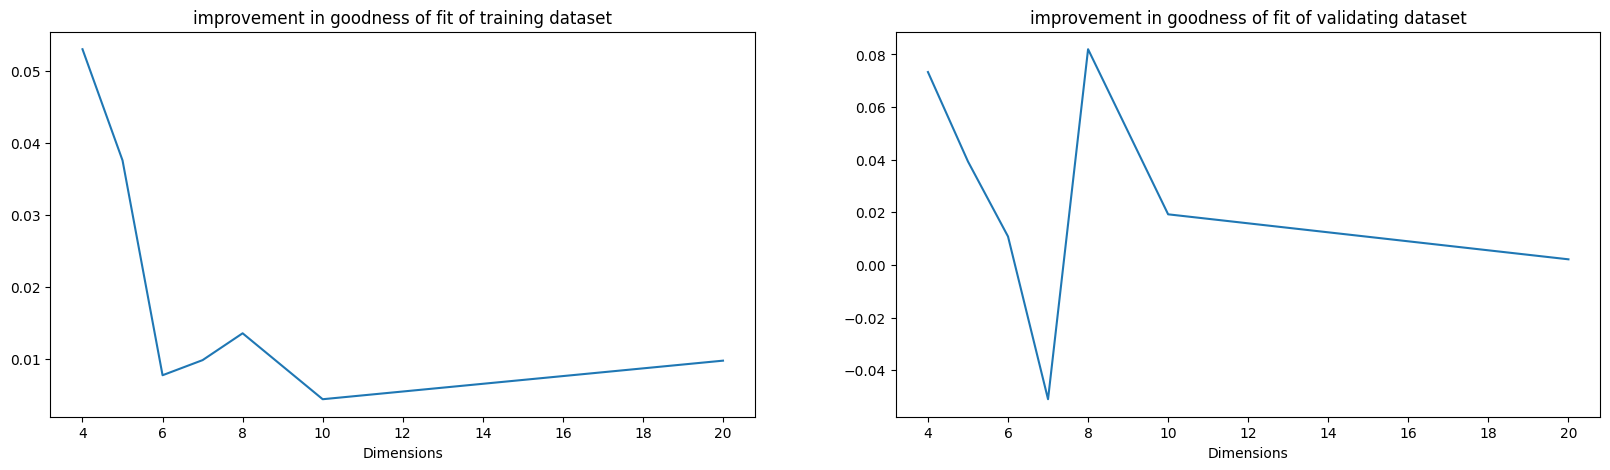

In [40]:
fig = plt.figure(figsize=(20,5))
ax1 = fig.add_subplot(1,2,1)
ax1.plot([4,5,6,7,8,10,20], np.array(goodness_of_fit_train)[1:8] - np.array(goodness_of_fit_train)[0:7])
ax1.set_title('improvement in goodness of fit of training dataset')
ax1.set_xlabel('Dimensions')
ax2 = fig.add_subplot(1,2,2)
ax2.plot([4,5,6,7,8,10,20], np.array(goodness_of_fit_valid)[1:8] - np.array(goodness_of_fit_valid)[0:7])
ax2.set_title('improvement in goodness of fit of validating dataset')
ax2.set_xlabel('Dimensions')

10D seems to be the best model

In [42]:
dim = [3,4,5,6,7,8,10,20,50,100,150,200]
neuro_path = '/Users/elie/Library/CloudStorage/Box-Box/ManipBerkeleyZF/neuro_PurWhi_WF/'
filename = '%s/GoodnessFit_countData_ModOffset50_TimeOffset5_DimVar.pkl' % (neuro_path)
with open(filename, 'wb') as f:
    pickle.dump({'goodness_of_fit_train': goodness_of_fit_train, 'goodness_of_fit_valid': goodness_of_fit_valid, 'dimensions': dim}, f)